In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dropout, Dense

In [2]:
df = pd.read_csv("../data/raw/SBIN.csv")

# Remove any accidental index column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nStart Date:", df["Date"].min())
print("End Date:", df["Date"].max())

df.head()

Shape: (2878, 7)

Start Date: 2015-01-01 00:00:00
End Date: 2026-08-24 00:00:00


,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,274.924988,314.000000,315.000000,310.700012,312.450012,6138488
1,2015-01-02,276.019440,315.250000,318.299988,314.350006,314.350006,9935094
2,2015-01-05,273.830566,312.750000,316.799988,312.100006,316.250000,9136716
3,2015-01-06,262.579651,299.899994,311.100006,298.700012,310.000000,15329257
4,2015-01-07,262.798492,300.149994,302.549988,295.149994,300.000000,15046745


In [3]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Total records:", len(df))
print("Training records:", len(train))
print("Testing records:", len(test))

print("\nTrain period:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest period:")
print(test["Date"].min(), "to", test["Date"].max())

Total records: 2878
Training records: 2302
Testing records: 576

Train period:
2015-01-01 00:00:00 to 2024-05-02 00:00:00

Test period:
2024-05-03 00:00:00 to 2026-08-24 00:00:00


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Extract Close price
train_close = train[["Close"]]
test_close = test[["Close"]]

# Fit only on training data
train_scaled = scaler.fit_transform(train_close)

# Transform test data using the same scaler
test_scaled = scaler.transform(test_close)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nFirst 5 scaled training values:")
print(train_scaled[:5])

print("\nFirst 5 scaled testing values:")
print(test_scaled[:5])

Train scaled shape: (2302, 1)
Test scaled shape: (576, 1)

First 5 scaled training values:
[[0.24020907]
 [0.24204947]
 [0.23836867]
 [0.21944934]
 [0.21981742]]

First 5 scaled testing values:
[[1.00206128]
 [0.96724087]
 [0.95855423]
 [0.97165783]
 [0.98490872]]


In [5]:
lookback = 60

X_train = []
y_train = []

for i in range(lookback, len(train_scaled)):
    X_train.append(train_scaled[i - lookback:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nFirst sequence:")
print(X_train[0][:10])

print("\nTarget:")
print(y_train[0])

X_train shape: (2242, 60)
y_train shape: (2242,)

First sequence:
[0.24020907 0.24204947 0.23836867 0.21944934 0.21981742 0.22673734
 0.22430802 0.23005007 0.22710542 0.22651651]

Target:
0.17108360545065887


In [6]:
# Combine last 60 training values with test values
test_input = np.concatenate(
    (train_scaled[-lookback:], test_scaled),
    axis=0
)

X_test = []
y_test = []

for i in range(lookback, len(test_input)):
    X_test.append(test_input[i - lookback:i, 0])
    y_test.append(test_input[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test input shape:", test_input.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nExpected test predictions:", len(X_test))

Test input shape: (636, 1)
X_test shape: (576, 60)
y_test shape: (576,)

Expected test predictions: 576


In [7]:
# Reshape training data
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

# Reshape testing data
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2242, 60, 1)
y_train shape: (2242,)

X_test shape: (576, 60, 1)
y_test shape: (576,)


In [8]:
model = Sequential([
    
    Input(shape=(X_train.shape[1], 1)),
    
    # CNN layer - detects local patterns
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),
    
    # Reduce sequence size
    MaxPooling1D(pool_size=2),
    
    # LSTM layer - learns time dependencies
    LSTM(50),
    
    # Prevent overfitting
    Dropout(0.2),
    
    # Dense layers
    Dense(25, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 58, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 50)                  │          23,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,557 (95.93 KB)

 Trainable params: 24,557 (95.93 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0210 - val_loss: 0.0017
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8451e-04 - val_loss: 0.0013
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6030e-04 - val_loss: 0.0010
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6925e-04 - val_loss: 0.0011
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6508e-04 - val_loss: 0.0011
Epoch 12/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s

In [10]:
# Generate predictions
cnn_lstm_predictions = model.predict(X_test)

# Convert predictions back to original stock price scale
cnn_lstm_predictions = scaler.inverse_transform(cnn_lstm_predictions)

# Convert actual test values back to original scale
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predictions shape:", cnn_lstm_predictions.shape)
print("Actual prices shape:", actual_prices.shape)

print("\nFirst 5 predictions:")

for i in range(5):
    print(
        f"Actual: ₹{actual_prices[i][0]:.2f} | "
        f"Predicted: ₹{cnn_lstm_predictions[i][0]:.2f}"
    )

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions shape: (576, 1)
Actual prices shape: (576, 1)

First 5 predictions:
Actual: ₹831.45 | Predicted: ₹798.82
Actual: ₹807.80 | Predicted: ₹796.01
Actual: ₹801.90 | Predicted: ₹793.56
Actual: ₹810.80 | Predicted: ₹770.97
Actual: ₹819.80 | Predicted: ₹773.13


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_prices, cnn_lstm_predictions)

rmse = np.sqrt(
    mean_squared_error(actual_prices, cnn_lstm_predictions)
)

mape = np.mean(
    np.abs(
        (actual_prices - cnn_lstm_predictions) / actual_prices
    )
) * 100

r2 = r2_score(actual_prices, cnn_lstm_predictions)

print("===== CNN-LSTM FORECAST RESULTS =====")
print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² Score: {r2:.4f}")

===== CNN-LSTM FORECAST RESULTS =====
MAE: ₹33.25
RMSE: ₹36.07
MAPE: 3.75%
R² Score: 0.9097


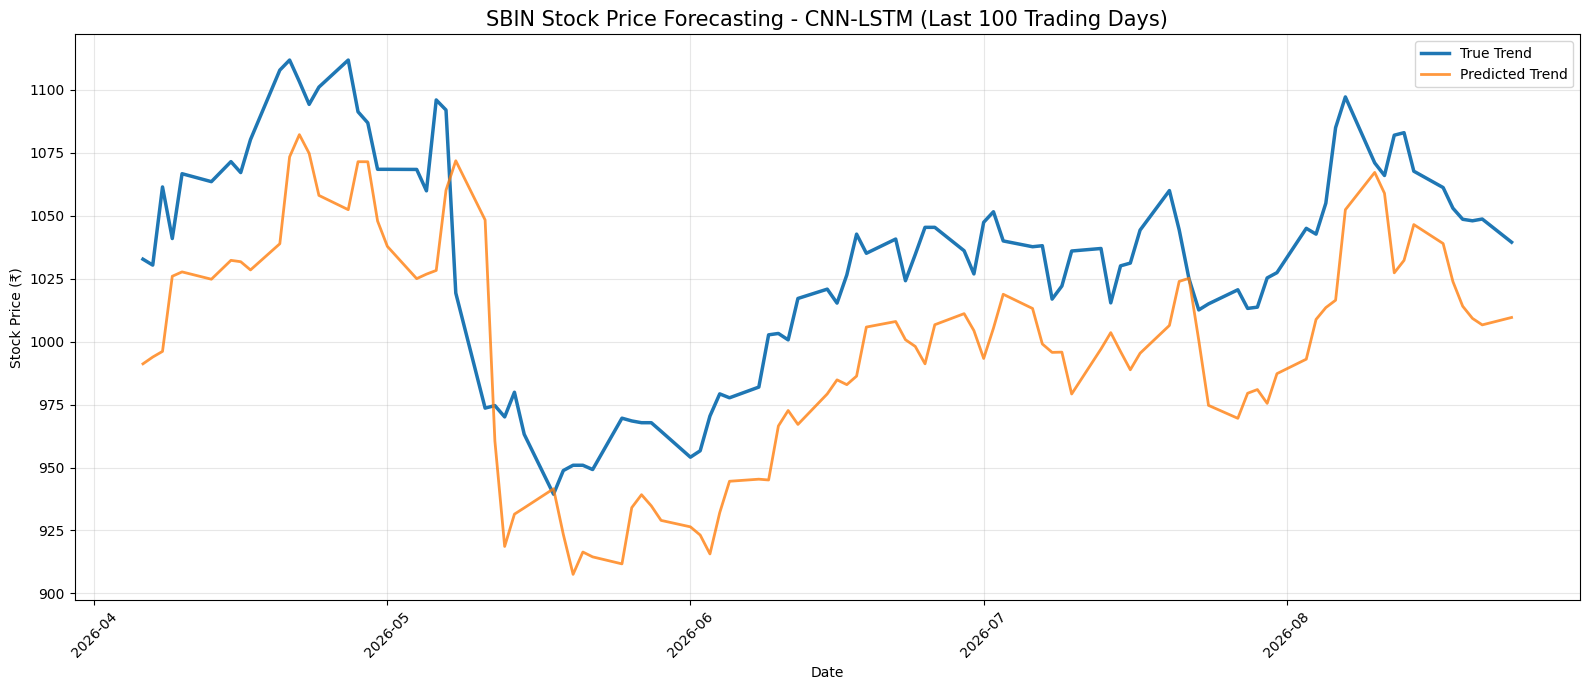

In [12]:
import matplotlib.pyplot as plt

last_n = 100

# Create test dates
test_dates = df["Date"].iloc[-len(actual_prices):]

plt.figure(figsize=(16, 7))

plt.plot(
    test_dates.iloc[-last_n:],
    actual_prices.flatten()[-last_n:],
    label="True Trend",
    linewidth=2.5
)

plt.plot(
    test_dates.iloc[-last_n:],
    cnn_lstm_predictions.flatten()[-last_n:],
    label="Predicted Trend",
    linewidth=2,
    alpha=0.8
)

plt.title(
    "SBIN Stock Price Forecasting - CNN-LSTM (Last 100 Trading Days)",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()